# **Testing a Percentile Threshold Uniformly over Aus & per grid-cell for Solar**

AUS Wide Percentile Threshold: 0.10 (10%)
Per Grid-Cell: 0.10 per-grid cell

# **AUS Wide Threshold**

In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import dask
from dask.diagnostics import ProgressBar
import cartopy.crs as ccrs
import cartopy.feature as cfeature

solar_cf_path = "/home/563/ft3359/GC26-combined-solar-wind/data/raw/solar_cf"

# directory of netCDFs → open them all as one dataset
ds = xr.open_mfdataset(f"{solar_cf_path}/*.nc")
print(ds)

<xarray.Dataset> Size: 75GB
Dimensions:          (time: 736337, lat: 141, lon: 181)
Coordinates:
  * time             (time) datetime64[ns] 6MB 1940-01-01T07:00:00 ... 2023-1...
  * lat              (lat) float32 564B -10.0 -10.25 -10.5 ... -44.75 -45.0
  * lon              (lon) float32 724B 110.0 110.2 110.5 ... 154.5 154.8 155.0
Data variables:
    capacity_factor  (time, lat, lon) float32 75GB dask.array<chunksize=(8777, 141, 181), meta=np.ndarray>


In [2]:
var = 'capacity_factor'

# re-open
ds = xr.open_mfdataset(f"{solar_cf_path}/*.nc", chunks={'time': 24*30})
cf = ds[var]

# hourly -> daily mean
cf_daily = cf.resample(time='1D').mean()

# Group to Winter months: May – September
winter = cf_daily.sel(time=cf_daily.time.dt.month.isin([5, 6, 7, 8, 9]))

# materialise once
with ProgressBar():
    winter = winter.load()


########################################] | 100% Completed | 285.15 s

In [3]:
QUANTILES = [0.10]

# pooled over time + lat + lon -> flat AUS wide winter threshold
thr_aus = winter.quantile(QUANTILES)
print(thr_aus)

<xarray.DataArray 'capacity_factor' (quantile: 1)> Size: 8B
array([0.075666])
Coordinates:
  * quantile  (quantile) float64 8B 0.1


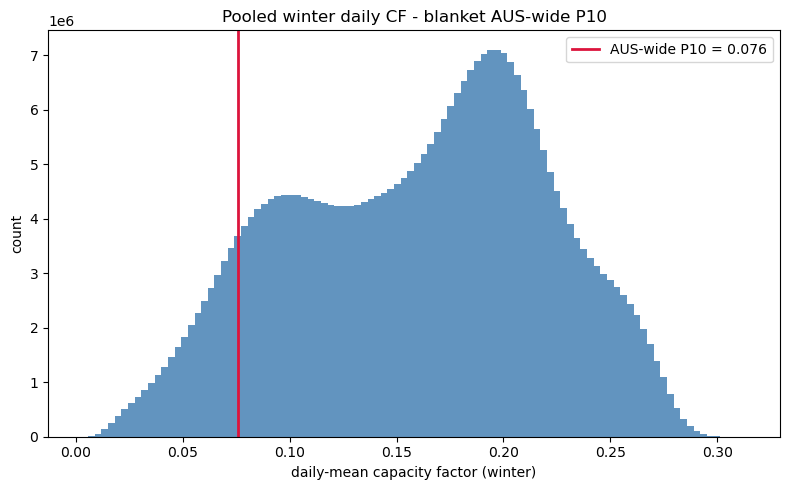

0.025575343519449234 0.16761936247348785


In [8]:
p10 = float(thr_aus.sel(quantile=0.10))

vals = winter.values.ravel()
vals = vals[~np.isnan(vals)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(vals, bins=100, color='steelblue', alpha=0.85)
ax.axvline(p10, color='crimson', lw=2, label=f'AUS-wide P10 = {p10:.3f}')
ax.set_xlabel('daily-mean capacity factor (winter)')
ax.set_ylabel('count')
ax.set_title('Pooled winter daily CF - blanket AUS-wide P10')
ax.legend()
plt.tight_layout()
plt.show()

print(float(winter.mean()), float(winter.median()))

In [9]:
print('min/max:', float(winter.min()), float(winter.max()))
print('frac < 0:', float((winter < 0).mean()))
print('frac ==0:', float((winter ==0).mean()))
print('frac NaN:', float(winter.isnull().mean()))

min/max: 0.002685729181393981 0.313721239566803
frac < 0: 0.0
frac ==0: 0.0
frac NaN: 0.0


# **Per Grid-Cell Threshold for Solar**

In [11]:
thr_cell = winter.quantile(QUANTILES, dim='time')
print(thr_cell)

<xarray.DataArray 'capacity_factor' (quantile: 1, lat: 141, lon: 181)> Size: 204kB
array([[[0.180394  , 0.18054256, 0.18068493, ..., 0.12322875,
         0.12287814, 0.12322457],
        [0.18046641, 0.18022568, 0.18050716, ..., 0.12362047,
         0.12326092, 0.12328078],
        [0.18025064, 0.18056665, 0.18049923, ..., 0.12493014,
         0.12464992, 0.12483064],
        ...,
        [0.03155965, 0.03140813, 0.03147641, ..., 0.04447584,
         0.04458148, 0.04456163],
        [0.03053581, 0.03055776, 0.03088837, ..., 0.04354683,
         0.04375159, 0.04355453],
        [0.02994607, 0.02970227, 0.02977752, ..., 0.04295914,
         0.04301736, 0.04284066]]])
Coordinates:
  * quantile  (quantile) float64 8B 0.1
  * lat       (lat) float32 564B -10.0 -10.25 -10.5 ... -44.5 -44.75 -45.0
  * lon       (lon) float32 724B 110.0 110.2 110.5 110.8 ... 154.5 154.8 155.0


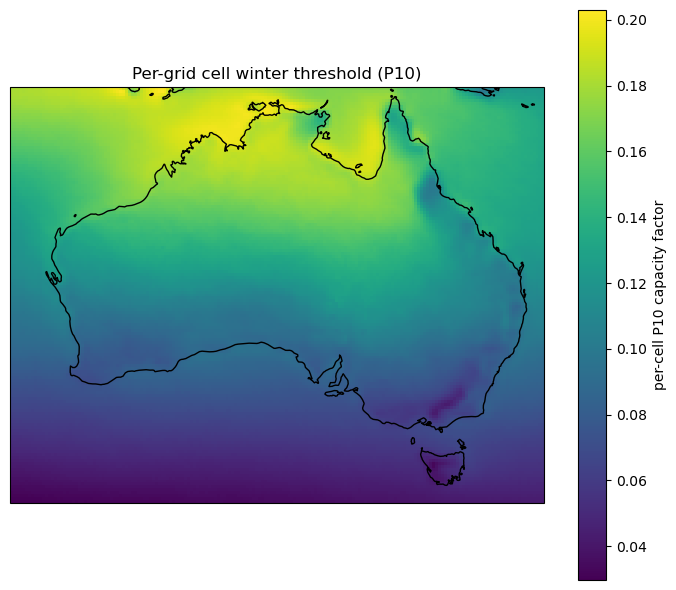

In [12]:
P = 0.10
tc = thr_cell.sel(quantile=P)

fig, ax = plt.subplots(figsize=(7, 6), subplot_kw={'projection': ccrs.PlateCarree()})
tc.plot(ax=ax, transform=ccrs.PlateCarree(),
        cbar_kwargs={'label': f'per-cell P{int(P*100)} capacity factor'})
ax.set_title('Per-grid cell winter threshold (P10)')
ax.coastlines()
ax.add_feature(cfeature.BORDERS, lw=0.3)
plt.tight_layout()
plt.show()

# **Testing a Percentile Threshold Uniformly over Aus & per grid-cell for Wind**

AUS Wide Percentile Threshold: 0.10 (10%)
Per Grid-Cell: 0.10 per-grid cell

# **AUS Wide Threshold**

In [13]:
wind_cf_path = "/home/563/ft3359/GC26-combined-solar-wind/data/raw/wind_cf"

# directory of netCDFs → open them all as one dataset
ds = xr.open_mfdataset(f"{wind_cf_path}/*.nc")
print(ds)

<xarray.Dataset> Size: 75GB
Dimensions:          (time: 736344, lat: 141, lon: 181)
Coordinates:
  * time             (time) datetime64[ns] 6MB 1940-01-01 ... 2023-12-31T23:0...
  * lat              (lat) float32 564B -10.0 -10.25 -10.5 ... -44.75 -45.0
  * lon              (lon) float32 724B 110.0 110.2 110.5 ... 154.5 154.8 155.0
Data variables:
    capacity_factor  (time, lat, lon) float32 75GB dask.array<chunksize=(8784, 141, 181), meta=np.ndarray>


In [23]:
varW = 'capacity_factor'

# re-open
Wds = xr.open_mfdataset(f"{wind_cf_path}/*.nc", chunks={'time': 24*30})
Wcf = Wds[varW]

# hourly -> daily mean
W_cf_daily = Wcf.resample(time='1D').mean()

# Group to Winter months: May – September
wind_winter = W_cf_daily.sel(time=W_cf_daily.time.dt.month.isin([5, 6, 7, 8, 9]))

# materialise once
with ProgressBar():
    wind_winter = wind_winter.load()


########################################] | 100% Completed | 386.60 s

In [24]:
Wind_QUANTILES = [0.10]

# pooled over time + lat + lon -> flat AUS wide winter wind threshold
thr_aus_wind = wind_winter.quantile(Wind_QUANTILES)
print(thr_aus_wind)

<xarray.DataArray 'capacity_factor' (quantile: 1)> Size: 8B
array([0.02203104])
Coordinates:
  * quantile  (quantile) float64 8B 0.1


In [26]:
print(float(thr_aus_wind.sel(quantile=0.10)))

0.022031037323176864


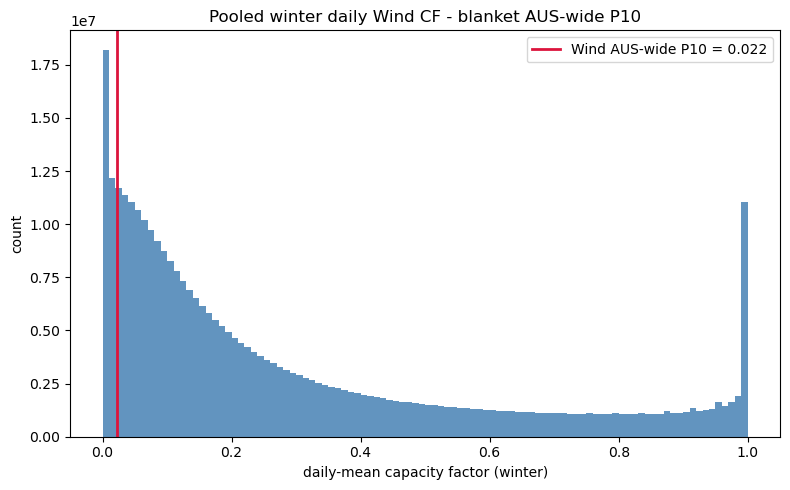

In [28]:
wind_p10 = float(thr_aus_wind.sel(quantile=0.10))

wind_vals = wind_winter.values.ravel()
wind_vals = wind_vals[~np.isnan(wind_vals)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(wind_vals, bins=100, color='steelblue', alpha=0.85)
ax.axvline(wind_p10, color='crimson', lw=2, label=f'Wind AUS-wide P10 = {wind_p10:.3f}')
ax.set_xlabel('daily-mean capacity factor (winter)')
ax.set_ylabel('count')
ax.set_title('Pooled winter daily Wind CF - blanket AUS-wide P10')
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
print('min/max:', float(wind_winter.min()), float(wind_winter.max()))
print('frac < 0:', float((wind_winter < 0).mean()))
print('frac ==0:', float((wind_winter ==0).mean()))
print('frac NaN:', float(wind_winter.isnull().mean()))

min/max: 0.0 1.0
frac < 0: 0.0
frac ==0: 0.00814968743571947
frac NaN: 0.0


# **Per Grid-Cell Threshold for Wind**

In [30]:
thr_cell_wind = winter.quantile(Wind_QUANTILES, dim='time')
print(thr_cell_wind)

<xarray.DataArray 'capacity_factor' (quantile: 1, lat: 141, lon: 181)> Size: 204kB
array([[[0.05006779, 0.04884528, 0.04874997, ..., 0.02509561,
         0.02357964, 0.02243268],
        [0.05150549, 0.0493351 , 0.0488974 , ..., 0.02875111,
         0.02713835, 0.02601699],
        [0.05310283, 0.05184292, 0.05056277, ..., 0.0320378 ,
         0.03051484, 0.02928937],
        ...,
        [0.27525796, 0.27210498, 0.27088777, ..., 0.09189053,
         0.09167894, 0.09057665],
        [0.28161905, 0.28213339, 0.27829979, ..., 0.09423318,
         0.09371548, 0.0933595 ],
        [0.28584794, 0.28860962, 0.28665634, ..., 0.09747689,
         0.09722978, 0.09617882]]])
Coordinates:
  * quantile  (quantile) float64 8B 0.1
  * lat       (lat) float32 564B -10.0 -10.25 -10.5 ... -44.5 -44.75 -45.0
  * lon       (lon) float32 724B 110.0 110.2 110.5 110.8 ... 154.5 154.8 155.0


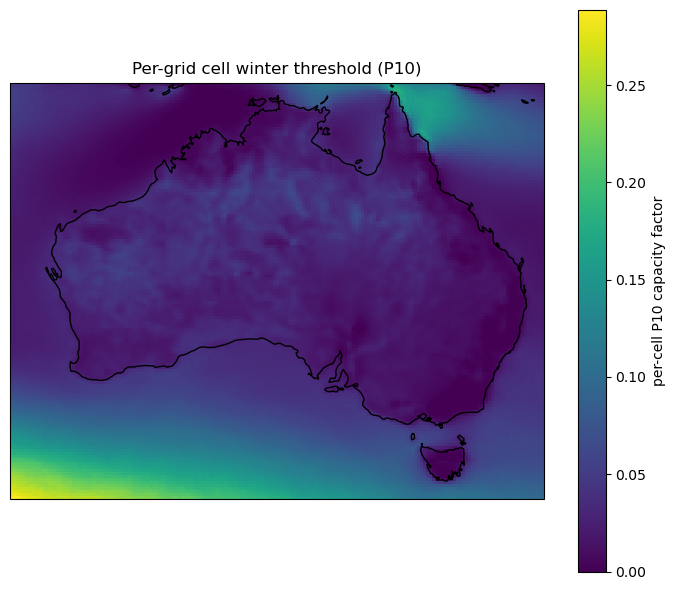

In [31]:
wind_P = 0.10
tc_wind = thr_cell_wind.sel(quantile=wind_P)

fig, ax = plt.subplots(figsize=(7, 6), subplot_kw={'projection': ccrs.PlateCarree()})
tc_wind.plot(ax=ax, transform=ccrs.PlateCarree(),
        cbar_kwargs={'label': f'per-cell P{int(wind_P*100)} capacity factor'})
ax.set_title('Per-grid cell winter threshold (P10)')
ax.coastlines()
ax.add_feature(cfeature.BORDERS, lw=0.3)
plt.tight_layout()
plt.show()

In [37]:
P = 0.10

# check for same winter days 
sol, wnd = xr.align(winter, wind_winter, join='inner')

solar_lull = sol < thr_cell.sel(quantile=P)
wind_lull = wnd < thr_cell_wind.sel(quantile=P)
compound = solar_lull & wind_lull

co_freq = compound.mean('time')
co_n = compound.sum('time')

#print(f"Compound Frequency:", co_freq)
#print(f"Compound Number:", co_n)

In [38]:
p_solar = solar_lull.mean('time')
p_wind = wind_lull.mean('time')
expected = p_solar * p_wind
ratio = co_freq / expected

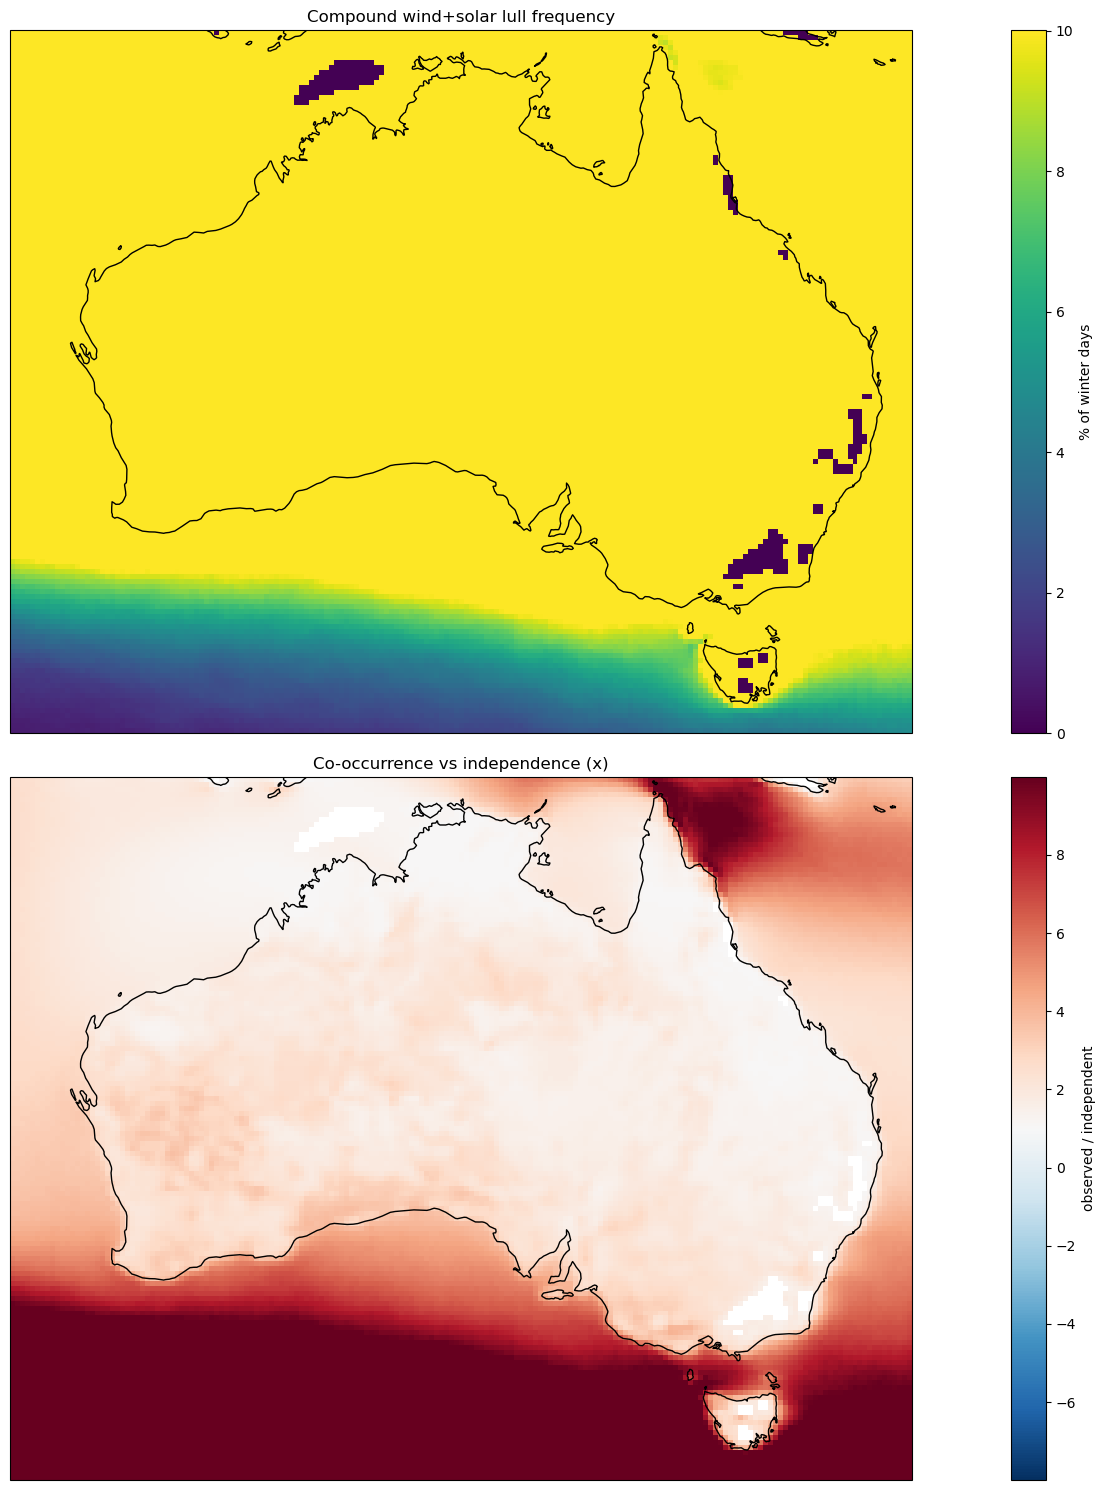

In [44]:
fig, axes = plt.subplots(2, 1, figsize=(20, 15),
                         subplot_kw={'projection': ccrs.PlateCarree()})

(100 * co_freq).plot(ax=axes[0], transform=ccrs.PlateCarree(),
                     cbar_kwargs={'label': '% of winter days'})
axes[0].set_title('Compound wind+solar lull frequency')

ratio.plot(ax=axes[1], transform=ccrs.PlateCarree(),
           cmap='RdBu_r', center=1,
           cbar_kwargs={'label': 'observed / independent'})
axes[1].set_title('Co-occurrence vs independence (x)')


for ax in axes: 
    ax.coastlines(); ax.add_feature(cfeature.BORDERS, lw=0.3)
plt.tight_layout()
plt.show()

In [48]:
def compound_lull_diagnostics(solar_path, wind_path, p=0.10, run_len=3,
                              months=(5, 6, 7, 8, 9), var='capacity_factor'):

    def min_run_mask(mask, n, dim='time'):
        window_full = (mask.astype('int8').rolling({dim: n}, min_periods=n).sum() == n)
        out = xr.zeros_like(mask, dtype=bool)
        for k in range(n):
            out = out | window_full.shift({dim: -k}).fillna(False)
        return out

    def winter_daily(path):
        cf = xr.open_mfdataset(f"{path}/*nc", chunks={'time': 24*30})[var]
        daily = cf.resample(time='1D').mean()
        wtr = daily.sel(time=daily.time.dt.month.isin(list(months)))
        with ProgressBar():
            return wtr.load()

    sol = winter_daily(solar_path)
    wnd = winter_daily(wind_path)
    sol, wnd = xr.align(sol, wnd, join='inner')

    thr_sol = sol.quantile(p, dim='time')
    thr_wnd = wnd.quantile(p, dim='time')

    solar_lull = min_run_mask(sol < thr_sol, run_len)
    wind_lull = min_run_mask(wnd < thr_wnd, run_len)

    compound = solar_lull & wind_lull
    co_freq = compound.mean('time')
    p_solar = solar_lull.mean('time')
    p_wind = wind_lull.mean('time')
    ratio = co_freq / (p_solar * p_wind)

    return xr.Dataset({'co_freq': co_freq, 'ratio': ratio,
                        'p_solar': p_solar, 'p_wind': p_wind,
                        'compound': compound})

res = compound_lull_diagnostics(solar_cf_path, wind_cf_path, p=0.10, run_len=3)
co_freq, ratio = res['co_freq'], res['ratio']
print(res)



<xarray.Dataset> Size: 3GB
Dimensions:   (lon: 181, lat: 141, time: 12852)
Coordinates:
  * lon       (lon) float32 724B 110.0 110.2 110.5 110.8 ... 154.5 154.8 155.0
  * lat       (lat) float32 564B -10.0 -10.25 -10.5 ... -44.5 -44.75 -45.0
  * time      (time) datetime64[ns] 103kB 1940-05-01 1940-05-02 ... 2023-09-30
    quantile  float64 8B 0.1
Data variables:
    co_freq   (lat, lon) float64 204kB 0.01307 0.01229 ... 0.0006225 0.0005447
    ratio     (lat, lon) float64 204kB 3.936 3.632 3.752 ... 1.69 1.233 1.034
    p_solar   (lat, lon) float64 204kB 0.05112 0.0526 ... 0.02015 0.02039
    p_wind    (lat, lon) float64 204kB 0.06497 0.06435 ... 0.02505 0.02583
    compound  (time, lat, lon) object 3GB False False False ... False False


In [49]:
print(res)

<xarray.Dataset> Size: 3GB
Dimensions:   (lon: 181, lat: 141, time: 12852)
Coordinates:
  * lon       (lon) float32 724B 110.0 110.2 110.5 110.8 ... 154.5 154.8 155.0
  * lat       (lat) float32 564B -10.0 -10.25 -10.5 ... -44.5 -44.75 -45.0
  * time      (time) datetime64[ns] 103kB 1940-05-01 1940-05-02 ... 2023-09-30
    quantile  float64 8B 0.1
Data variables:
    co_freq   (lat, lon) float64 204kB 0.01307 0.01229 ... 0.0006225 0.0005447
    ratio     (lat, lon) float64 204kB 3.936 3.632 3.752 ... 1.69 1.233 1.034
    p_solar   (lat, lon) float64 204kB 0.05112 0.0526 ... 0.02015 0.02039
    p_wind    (lat, lon) float64 204kB 0.06497 0.06435 ... 0.02505 0.02583
    compound  (time, lat, lon) object 3GB False False False ... False False


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), 
                         subplot_kw={'projection': ccrs.PlateCarree()})
